In [59]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [60]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_elements, build_load_vector, apply_restraints,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [61]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [62]:
# General model parameters
L = 5000 
number_floors = 10
floor_height = 3500
H = floor_height * number_floors
B = 350

lc = 500

output_path = os.getcwd()
mesh_name = 'sw_00'
output_file = os.path.join(output_path, mesh_name + '.msh')
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [63]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)
# Create points for each floor level
# Bottom points
points_left = [gmsh.model.geo.addPoint(0, 0, 0, lc)]  # p1
points_center = [gmsh.model.geo.addPoint(L/2, 0, 0, lc)]  # p5
points_right = [gmsh.model.geo.addPoint(L, 0, 0, lc)]  # p2
# Create points at each floor level
for i in range(1, number_floors + 1):
    y = i * floor_height
    points_left.append(gmsh.model.geo.addPoint(0, y, 0, lc))
    points_center.append(gmsh.model.geo.addPoint(L/2, y, 0, lc))
    points_right.append(gmsh.model.geo.addPoint(L, y, 0, lc))
# Create horizontal and vertical lines for each floor
surfaces_left = []
surfaces_right = []
bottom_lines = []  # Store bottom lines for supports
floor_top_lines = []  # Store top lines of each floor for distributed loads

for i in range(number_floors):
    # Horizontal lines (bottom and top of each floor)
    h_bottom_left = gmsh.model.geo.addLine(points_left[i], points_center[i])
    h_bottom_right = gmsh.model.geo.addLine(points_center[i], points_right[i])
    h_top_left = gmsh.model.geo.addLine(points_left[i+1], points_center[i+1])
    h_top_right = gmsh.model.geo.addLine(points_center[i+1], points_right[i+1])
    
    # Save bottom lines only for first floor (i==0)
    if i == 0:
        bottom_lines.extend([h_bottom_left, h_bottom_right])
    
    # Save top lines of each floor for distributed loads
    floor_top_lines.extend([h_top_left, h_top_right])
    
    # Vertical lines
    v_left = gmsh.model.geo.addLine(points_left[i], points_left[i+1])
    v_center = gmsh.model.geo.addLine(points_center[i], points_center[i+1])
    v_right = gmsh.model.geo.addLine(points_right[i], points_right[i+1])
    
    # Create surfaces for left half
    curve_loop_left = gmsh.model.geo.addCurveLoop([h_bottom_left, v_center, -h_top_left, -v_left])
    surface_left = gmsh.model.geo.addPlaneSurface([curve_loop_left])
    surfaces_left.append(surface_left)
    
    # Create surfaces for right half
    curve_loop_right = gmsh.model.geo.addCurveLoop([h_bottom_right, v_right, -h_top_right, -v_center])
    surface_right = gmsh.model.geo.addPlaneSurface([curve_loop_right])
    surfaces_right.append(surface_right)
# Synchronize the model
gmsh.model.geo.synchronize()
# Create physical groups for all surfaces
all_surfaces = surfaces_left + surfaces_right
gmsh.model.addPhysicalGroup(2, all_surfaces, 201)
gmsh.model.setPhysicalName(2, 201, "Wall")
# Supports at entire bottom line (y=0) - NOW AS LINES
gmsh.model.addPhysicalGroup(1, bottom_lines, 101)
gmsh.model.setPhysicalName(1, 101, "Support_base")
# LOADS SECTION
# Pload_lateral at top left corner (x=0, y=H)
gmsh.model.addPhysicalGroup(0, [points_left[-1]], 301)
gmsh.model.setPhysicalName(0, 301, "Pload_lateral")
# Distributed vertical loads on top lines of each floor
gmsh.model.addPhysicalGroup(1, floor_top_lines, 302)
gmsh.model.setPhysicalName(1, 302, "Pload_vertical_distributed")
# Synchronize the model
gmsh.model.geo.synchronize()
def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
    
all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)

In [64]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [65]:
# Define material
fc_21 = Material(name='fc_21',
                 E=19185.1,
                 nu=0.20,
                 rho= 2400*kg/m**3*g*0)

# Define membrane section
ConcreteWall = Membrane(name='ConcreteWall',
                        thickness=B,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteWall}

# Define distributed load magnitude  {physical_id: [x load, y load]}
Pload_vertical = 411879.31/5000/B
Pload_lateral = 98066.5

load_dictionary = {
    302: {'value': Pload_vertical, 'direction': '-y'},   
    301: {'value': Pload_lateral,  'direction': 'x'},  
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       }

# Define self-weight (not used)
self_weight = [0, 0]

In [66]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

system_nDof = mesh.system_nDof
node_map = mesh.node_map


  MESH SUMMARY

  === NODES ===  (1143 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      2500.0000         0.0000         0.0000
       3      5000.0000         0.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     301      0   'Pload_lateral'
     101      1   'Support_base'
     302      1   'Pload_vertical_distributed'
     201      2   'Wall'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     301      0       15   

In [67]:
# apply boundary conditions onto mesh.node_map
apply_restraints(mesh, restrain_dictionary)


In [68]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# build FEM elements
elements = build_elements(
    mesh               = mesh,
    node_map           = mesh.node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStress',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

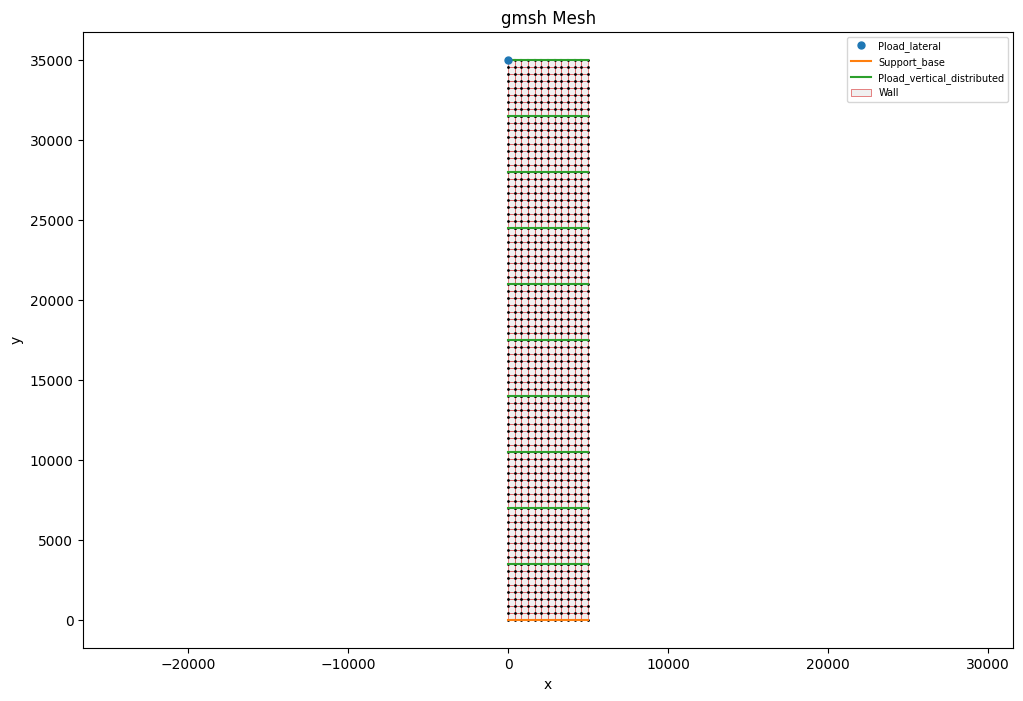

In [69]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = True,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [70]:
# Load vector
F_nodal = build_load_vector(mesh, 
                            load_dictionary)

In [71]:

F_load = np.zeros(system_nDof)

for tag, f_vec in F_nodal.items():
    if tag in mesh.node_map:
        F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec

for elem in elements:
    F_load[elem.idx] += elem.F_fe_body

In [72]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in node_map.values():
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [73]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-37585.260172  Ry=-187638.812685
Node 2:  Rx=+1750.655201  Ry=+943.218504
Node 3:  Rx=-37870.059012  Ry=+188870.011635
Node 34:  Rx=-14148.876501  Ry=-278864.951301
Node 35:  Rx=-3966.205174  Ry=-214403.765422
Node 36:  Rx=+1443.724332  Ry=-156721.421215
Node 37:  Rx=+2615.190166  Ry=-101621.757474
Node 38:  Rx=+2139.704113  Ry=-49402.235172
Node 39:  Rx=+2109.908987  Ry=+51289.015999
Node 40:  Rx=+2555.436962  Ry=+103511.537460
Node 41:  Rx=+1349.436386  Ry=+158620.954931
Node 42:  Rx=-4110.437192  Ry=+216322.658746
Node 43:  Rx=-14349.718097  Ry=+280863.526281
----------------------------------------------------------------------------------------------------
Applied X:  +98066.5000   Reaction X: -98066.5000   Balance: -1.0295e-07
Applied Y:  -11767.9803   Reaction Y: +11767.9803   Balance: -1.3364e-07


In [74]:
for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 4 at [   0. 3500.]:  Fx=-0.0000  Fy=-49.0333
Node 5 at [2500. 3500.]:  Fx=-0.0000  Fy=-98.0665
Node 6 at [5000. 3500.]:  Fx=-0.0000  Fy=-49.0333
Node 7 at [   0. 7000.]:  Fx=-0.0000  Fy=-49.0333
Node 8 at [2500. 7000.]:  Fx=-0.0000  Fy=-98.0665
Node 9 at [5000. 7000.]:  Fx=-0.0000  Fy=-49.0333
Node 10 at [    0. 10500.]:  Fx=-0.0000  Fy=-49.0333
Node 11 at [ 2500. 10500.]:  Fx=-0.0000  Fy=-98.0665
Node 12 at [ 5000. 10500.]:  Fx=-0.0000  Fy=-49.0333
Node 13 at [    0. 14000.]:  Fx=-0.0000  Fy=-49.0333
Node 14 at [ 2500. 14000.]:  Fx=-0.0000  Fy=-98.0665
Node 15 at [ 5000. 14000.]:  Fx=-0.0000  Fy=-49.0333
Node 16 at [    0. 17500.]:  Fx=-0.0000  Fy=-49.0333
Node 17 at [ 2500. 17500.]:  Fx=-0.0000  Fy=-98.0665
Node 18 at [ 5000. 17500.]:  Fx=-0.0000  Fy=-49.0333
Node 19 at [    0. 21000.]:  Fx=-0.0000  Fy=-49.0333
Node 20 at [ 2500. 21000.]:  Fx=-0.0000  Fy=-98.0665
Node 21 at [ 5000. 21000.]:  Fx=-0.0000  Fy=-49.0333
Node 22 at [    0. 24500.]:  Fx=-0.0000  Fy=-49.0333
Node 23 at 

In [75]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [76]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

add_node_data_view("Displacements",
                   node_tags,
                   u_3d,
                   vector_type=5,
                   factor=5)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [77]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [78]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [79]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [80]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 0])
add_node_data_view("Sxx Nodal Averaged",    
                    node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 1])
add_node_data_view("Syy Nodal Averaged",    
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 2])
add_node_data_view("Sxy Nodal Averaged",    
                    node_tags, sxy_nodal)

# -----------------
s1_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 0])
add_node_data_view("Principal Stress S1 Nodal Averaged", 
                    node_tags, s1_nodal)

# -----------------
s2_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 1])
add_node_data_view("Principal Stress S2 Nodal Averaged", 
                    node_tags, s2_nodal)

# -----------------
vm_nodal = compute_nodal_average(mesh, 
                                 element_tags_list, 
                                 von_mises_gmsh)
add_node_data_view("Von Mises Nodal Averaged",
                   node_tags, vm_nodal)

# -----------------
exx_nodal = compute_nodal_average(mesh, 
                                element_tags_list, 
                                epsilon_gmsh[:, 0])
add_node_data_view("Strain Exx Averaged", 
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

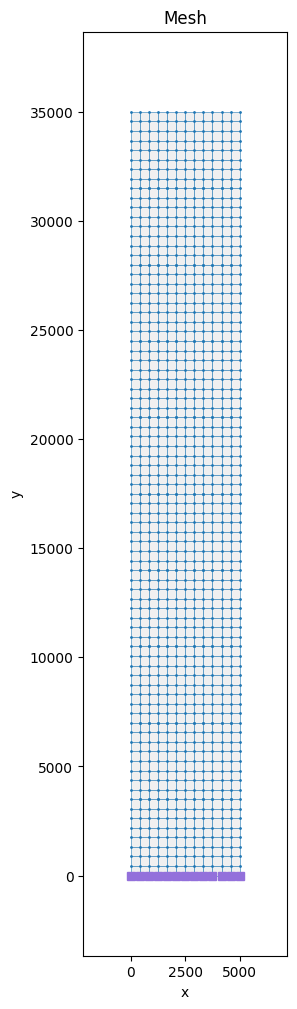

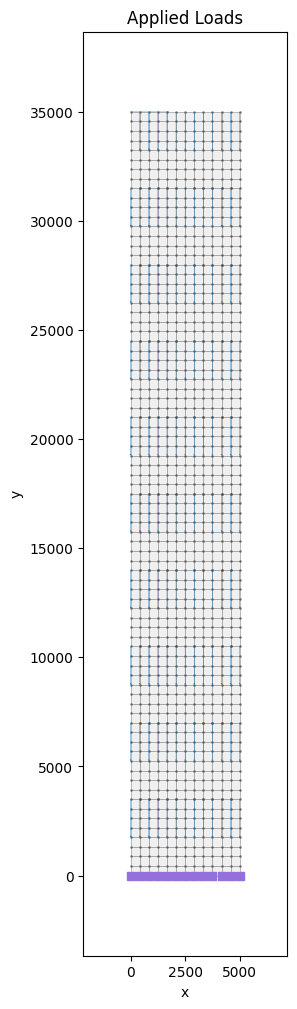

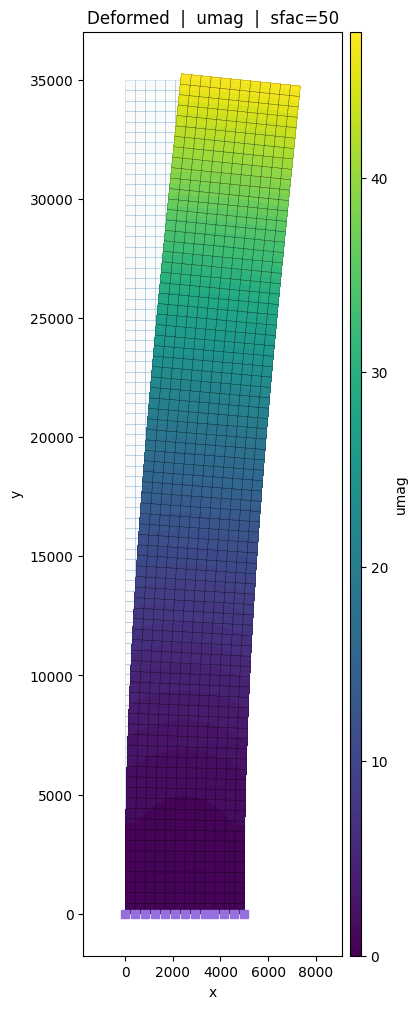

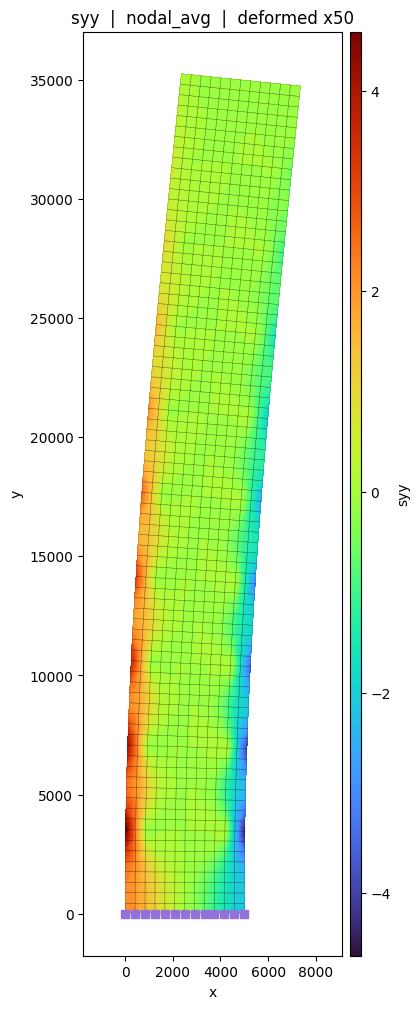

In [100]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 50,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'syy',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

## Opensees

In [87]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)

In [88]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [89]:
# Boundary conditions
constrained_nodes = set()

for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            if tag not in constrained_nodes:
                constrained_nodes.add(tag)
                ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [90]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               fc_21.E,
               fc_21.nu,
               fc_21.rho)

In [92]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('quad', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)
        # ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

<Axes: >

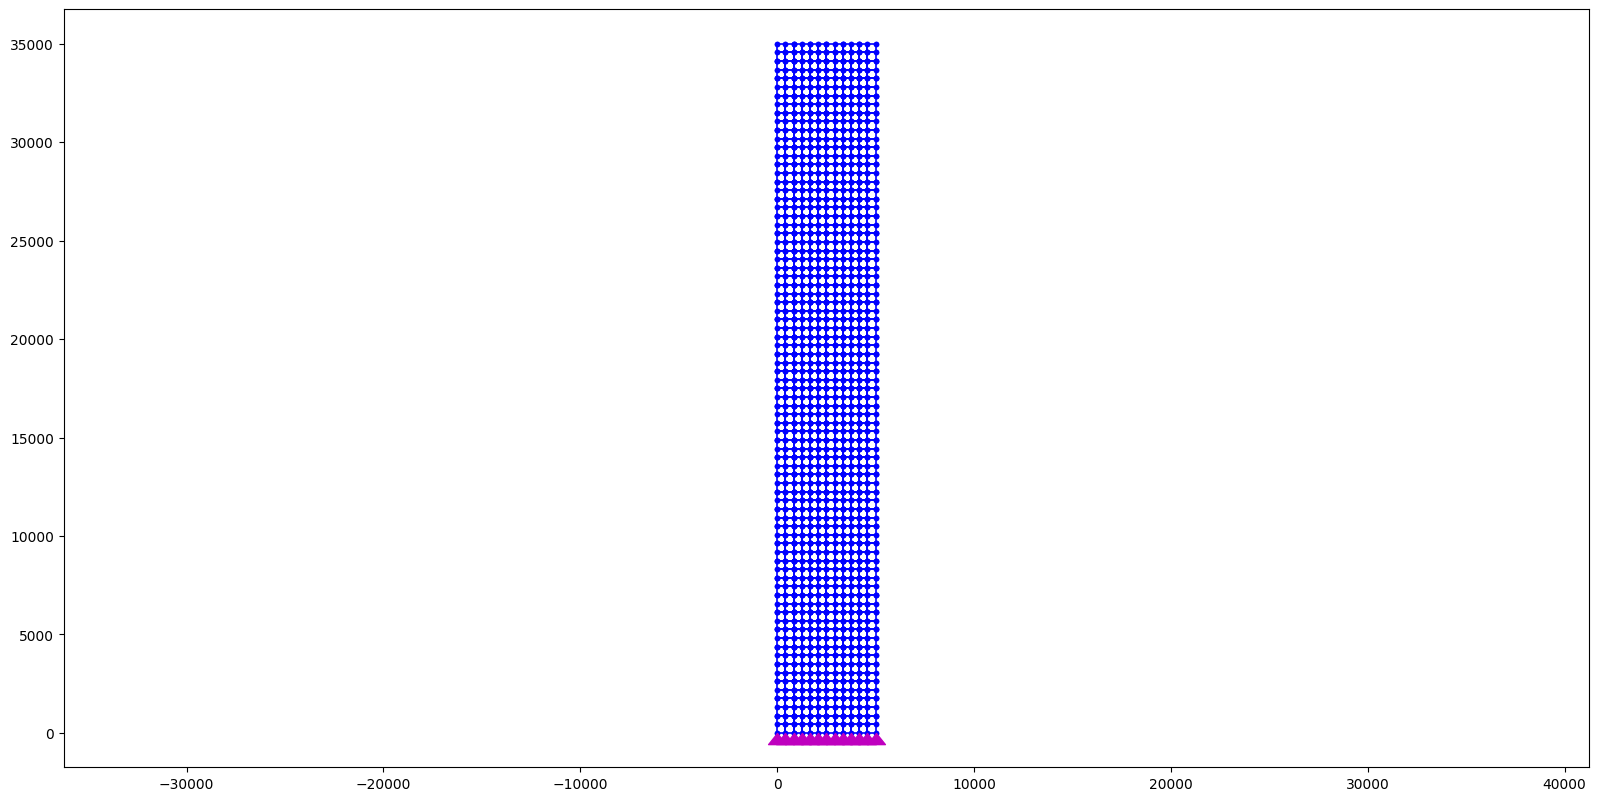

In [93]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [94]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))

In [95]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

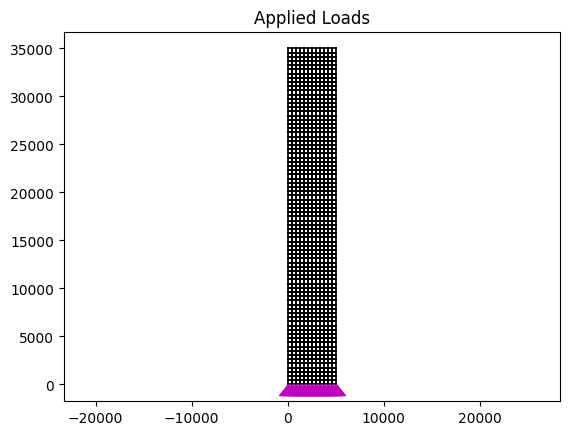

In [96]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

10

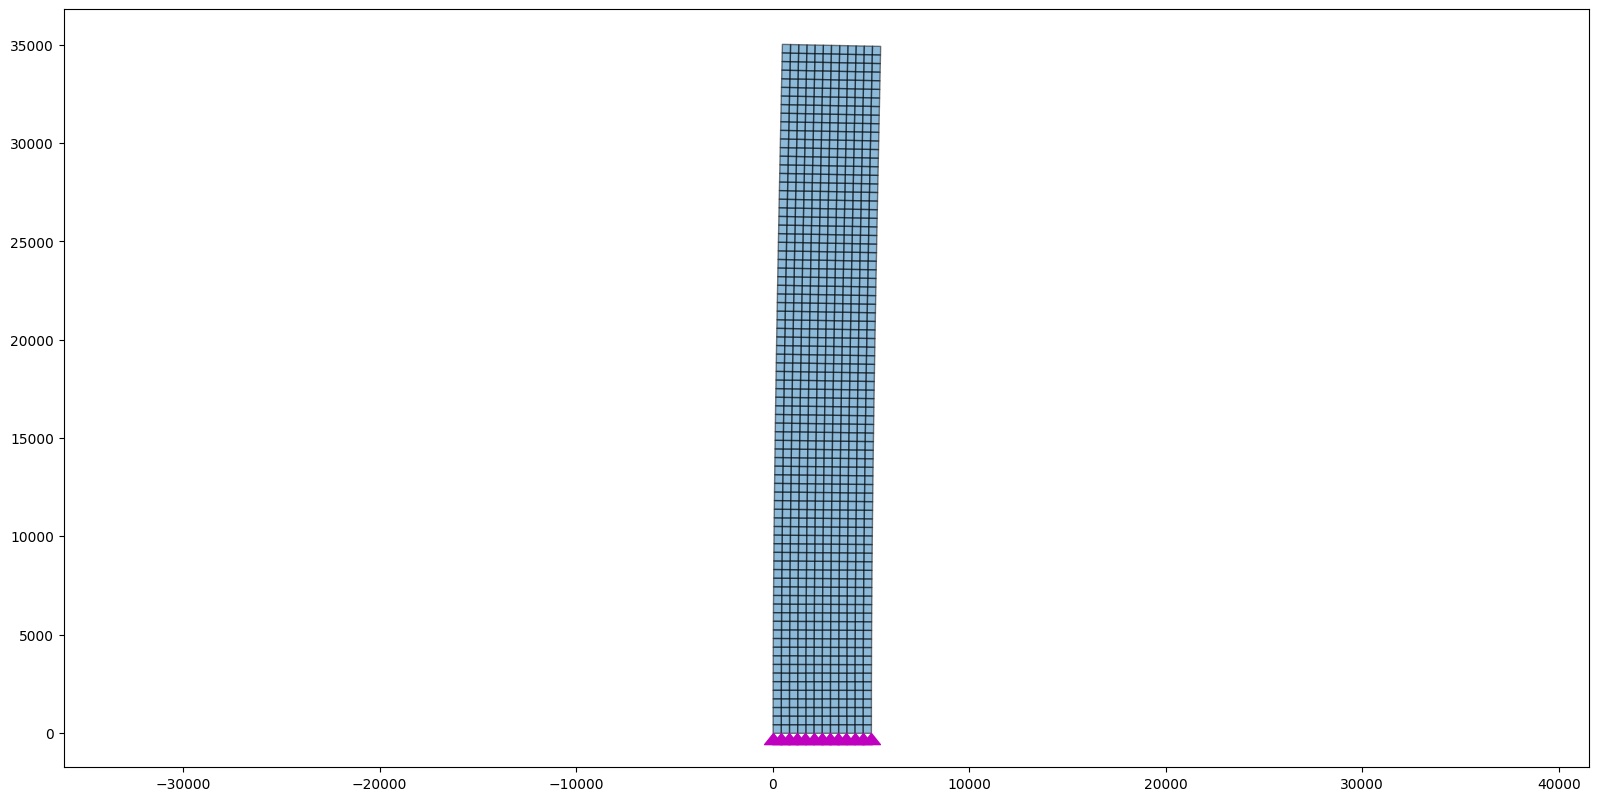

In [97]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'syy')

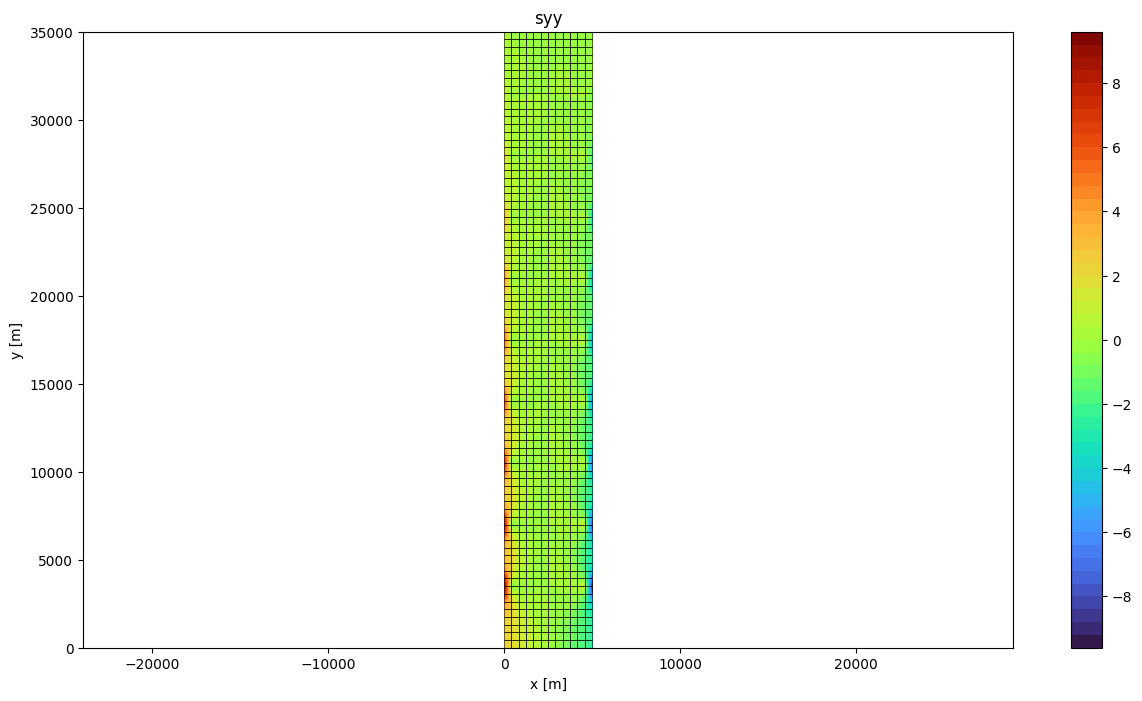

In [99]:
# jstr = 'sxx'
jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')